In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures, RobustScaler

In [2]:
df = pd.read_csv("crop_yield_cy.csv")
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [5]:
for i in ["Area","Item"]:
    df[i] = df[i].str.strip().str.title()

In [6]:
print(df["Area"].nunique())
print(df["Item"].nunique())

101
10


<Axes: >

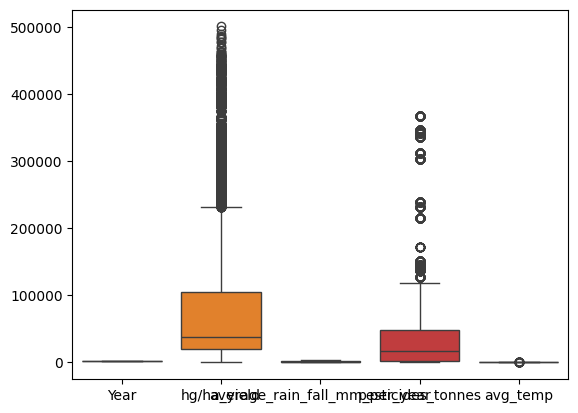

In [7]:
sns.boxplot(df)

In [8]:
Q1 = df["pesticides_tonnes"].quantile(0.25)
Q3 = df["pesticides_tonnes"].quantile(0.75)
IQR = Q3-Q1
df = df[(df['pesticides_tonnes'] >= Q1 - 1.5 * IQR) & (df['pesticides_tonnes'] <= Q3 + 1.5 * IQR)]

<Axes: >

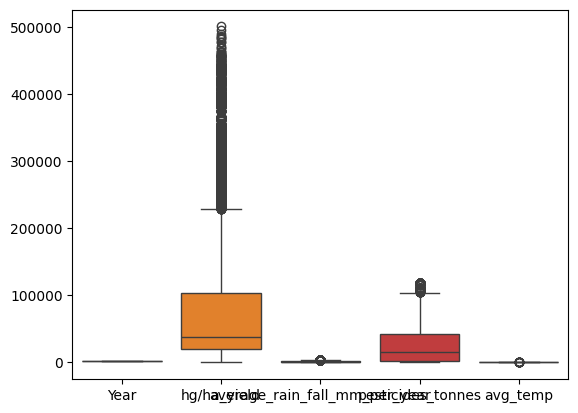

In [9]:
sns.boxplot(df)

In [10]:
df.corr(numeric_only=True)["hg/ha_yield"]

Year                             0.090753
hg/ha_yield                      1.000000
average_rain_fall_mm_per_year   -0.000588
pesticides_tonnes                0.115288
avg_temp                        -0.118562
Name: hg/ha_yield, dtype: float64

<Axes: xlabel='Area', ylabel='hg/ha_yield'>

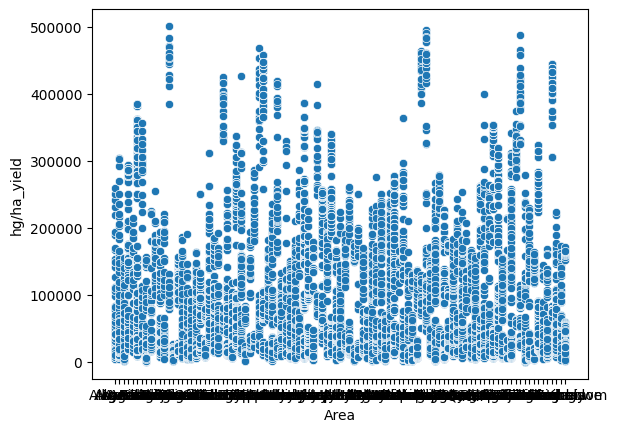

In [11]:
sns.scatterplot(df, x = "Area", y = "hg/ha_yield")

<Axes: xlabel='Item', ylabel='hg/ha_yield'>

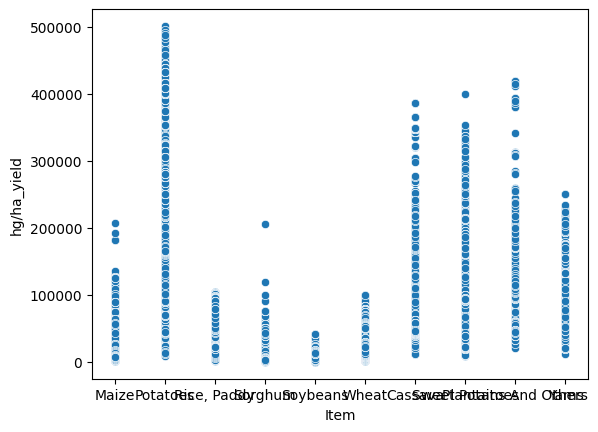

In [12]:
sns.scatterplot(df, x = "Item", y = "hg/ha_yield")

<Axes: xlabel='Year', ylabel='hg/ha_yield'>

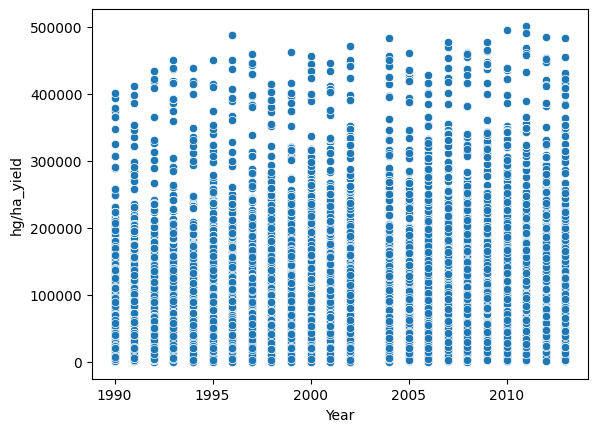

In [13]:
sns.scatterplot(df, x = "Year", y = "hg/ha_yield")

<Axes: xlabel='average_rain_fall_mm_per_year', ylabel='hg/ha_yield'>

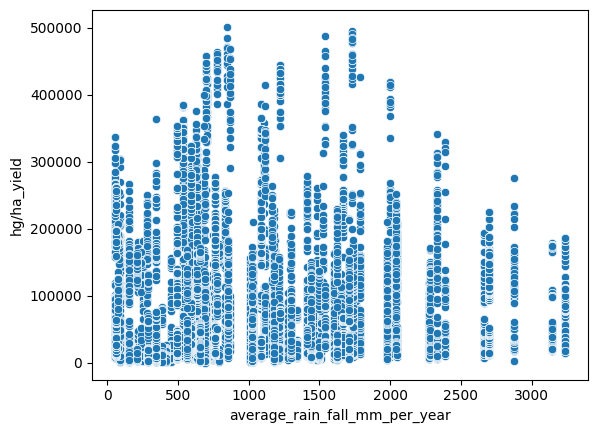

In [14]:
sns.scatterplot(df, x = "average_rain_fall_mm_per_year", y = "hg/ha_yield")

<Axes: xlabel='pesticides_tonnes', ylabel='hg/ha_yield'>

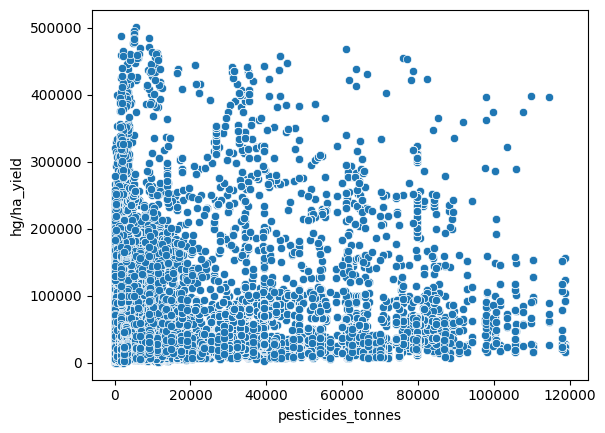

In [15]:
sns.scatterplot(df, x = "pesticides_tonnes", y = "hg/ha_yield")

<Axes: xlabel='avg_temp', ylabel='hg/ha_yield'>

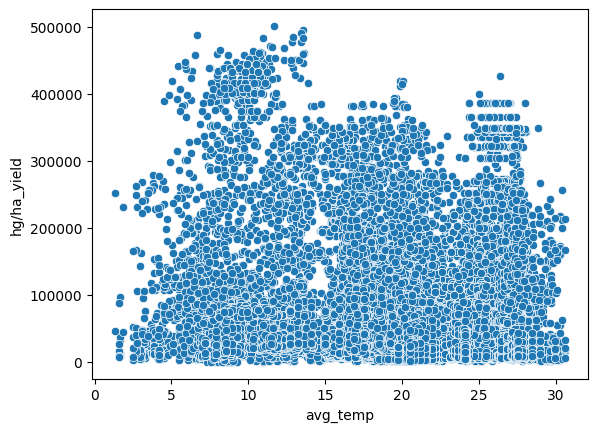

In [16]:
sns.scatterplot(df, x = "avg_temp", y = "hg/ha_yield")

In [17]:
x = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

In [18]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

In [19]:
num_cols = xtrain.select_dtypes(include="number").columns
cat_cols = xtrain.select_dtypes(include="object").columns

In [20]:
scaler = RobustScaler()
xtrain[num_cols] = scaler.fit_transform(xtrain[num_cols])

In [21]:
encoder = OrdinalEncoder(dtype=int, handle_unknown="use_encoded_value", unknown_value=-1)
xtrain[cat_cols] = encoder.fit_transform(xtrain[cat_cols])
xtrain

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
20186,62,8,0.615385,-0.348339,1.130385,-0.122917
773,4,3,0.000000,-0.558414,-0.360017,-1.179167
25800,86,6,0.307692,0.674169,-0.319785,0.544792
12791,42,0,0.230769,0.000000,0.487469,0.638542
2085,10,3,-0.846154,1.696677,-0.331310,0.466667
...,...,...,...,...,...,...
22993,73,5,0.769231,-0.631297,-0.314055,0.575000
6808,22,9,0.384615,2.311897,2.016693,0.114583
892,5,1,-0.692308,-0.588424,0.175919,-0.595833
17213,49,4,-0.307692,-0.892819,-0.165701,-1.455208


In [22]:
poly = PolynomialFeatures(degree=5)
xtrain_poly = poly.fit_transform(xtrain)

In [23]:
model = LinearRegression()
model.fit(xtrain_poly,ytrain)
model.score(xtrain_poly,ytrain)

0.554518598657542

In [24]:
xtest[num_cols] = scaler.transform(xtest[num_cols])
xtest[cat_cols] = encoder.transform(xtest[cat_cols])
xtest_poly = poly.transform(xtest)

In [25]:
model.score(xtest_poly,ytest)

0.5367658150414985

In [26]:
import joblib

In [27]:
joblib.dump(model, 'model.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(poly, 'poly.pkl')

['poly.pkl']

In [28]:
xtrain_poly

array([[ 1.00000000e+00,  6.20000000e+01,  8.00000000e+00, ...,
        -2.37292942e-03,  2.58029492e-04, -2.80578165e-05],
       [ 1.00000000e+00,  4.00000000e+00,  3.00000000e+00, ...,
        -2.12505638e-01, -6.96022395e-01, -2.27969092e+00],
       [ 1.00000000e+00,  8.60000000e+01,  6.00000000e+00, ...,
         1.65351428e-02, -2.81695633e-02,  4.79901690e-02],
       ...,
       [ 1.00000000e+00,  5.00000000e+00,  1.00000000e+00, ...,
        -6.54633032e-03,  2.21723103e-02, -7.50972405e-02],
       [ 1.00000000e+00,  4.90000000e+01,  4.00000000e+00, ...,
        -8.46107731e-02, -7.43063219e-01, -6.52568138e+00],
       [ 1.00000000e+00,  8.40000000e+01,  5.00000000e+00, ...,
        -2.08276386e-02,  4.56902458e-02, -1.00232129e-01]],
      shape=(21459, 462))